<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Welcome to ZZSC9020

This Python notebook shows how to clone the course GitHub repository on Google Colab.

You can develop your data analysis on Google Colab without downloading the data to your computer.

In [1]:
# This will remove all user-defined variables from the workspace
%reset -f

In [2]:


# Import any packages
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import plot_tree
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import holidays
# Get NSW public holidays
nsw_holidays = holidays.country_holidays('AU', subdiv='NSW')

# Joint forecastdemand_nsw files into a single file. 
!cat data/NSW/forecastdemand_nsw.csv.zip.part* > data/NSW/forecastdemand_nsw.csv.zip

# Unzip the data files into the data folder
!unzip -o data/NSW/forecastdemand_nsw.csv.zip -d data/NSW
!unzip -o data/NSW/temperature_nsw.csv.zip -d data/NSW
!unzip -o data/NSW/totaldemand_nsw.csv.zip -d data/NSW

# Remove forecastdemand_nsw.csv.zip
!rm data/NSW/forecastdemand_nsw.csv.zip

# the forecastdemand_nsw.csv file
df_forecast = pd.read_csv('data/NSW/forecastdemand_nsw.csv')

# the temperature_nsw.csv file
df_temperature = pd.read_csv('data/NSW/temperature_nsw.csv')

# inspect the totaldemand_nsw.csv file
df_totaldemand = pd.read_csv('data/NSW/totaldemand_nsw.csv')

# delete the unzipped files to save space
!rm data/NSW/forecastdemand_nsw.csv
!rm data/NSW/temperature_nsw.csv
!rm data/NSW/totaldemand_nsw.csv

# Convert all to pandas datetime and normalize to day-level
# Convert 'DATETIME' columns to datetime format (auto-infer format)
df_forecast['DATETIME'] = pd.to_datetime(df_forecast['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
df_temperature['DATETIME'] = pd.to_datetime(df_temperature['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
df_totaldemand['DATETIME'] = pd.to_datetime(df_totaldemand['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
# Group forecast by DATETIME and average
df_forecast_avg = df_forecast.groupby('DATETIME', as_index=False)['FORECASTDEMAND'].mean()

# Merge all DataFrames on 'DATETIME'
df_merged = df_forecast_avg.merge(df_totaldemand[['DATETIME', 'TOTALDEMAND']], on='DATETIME', how='left') \
                           .merge(df_temperature[['DATETIME', 'TEMPERATURE']], on='DATETIME', how='left')

# Resample by day and calculate min, max, and mean for TEMPERATURE
# Set 'DATETIME' as index before resampling
df_merged = df_merged.set_index('DATETIME')

df_daily = df_merged.resample('D').agg({
    'TEMPERATURE': ['min', 'max', 'mean'],
    'FORECASTDEMAND': 'mean',
    'TOTALDEMAND': 'mean'
})

print(df_daily.head())

Archive:  data/NSW/forecastdemand_nsw.csv.zip
  inflating: data/NSW/forecastdemand_nsw.csv  

Archive:  data/NSW/temperature_nsw.csv.zip
  inflating: data/NSW/temperature_nsw.csv  
Archive:  data/NSW/temperature_nsw.csv.zip
  inflating: data/NSW/temperature_nsw.csv  
Archive:  data/NSW/totaldemand_nsw.csv.zip
  inflating: data/NSW/totaldemand_nsw.csv  
Archive:  data/NSW/totaldemand_nsw.csv.zip
  inflating: data/NSW/totaldemand_nsw.csv  
           TEMPERATURE                  FORECASTDEMAND  TOTALDEMAND
                   min   max       mean           mean         mean
DATETIME                                                           
2010-01-01        22.1  28.8  25.185417    7723.688982  7801.352917
2010-01-02        22.2  29.4  24.795833    7804.668591  8017.459792
2010-01-03        17.9  21.5  19.462500    7491.520488  7399.899583
2010-01-04        17.9  23.9  20.847917    8592.014274  8241.720208
2010-01-05        15.4  27.7  22.660417    8907.999454  8827.813125
           TEM

In [3]:

# Create binary features for extreme temperature events
df_daily['IS_EXTREME_HOT'] = (df_daily['TEMPERATURE']['max'] > 35).astype(bool)
df_daily['IS_EXTREME_COLD'] = (df_daily['TEMPERATURE']['min'] < 5).astype(bool)

print(df_daily.head())

# Base performance
base_mse = mean_squared_error(df_daily['TOTALDEMAND']['mean'], df_daily['FORECASTDEMAND']['mean'])
base_r2 = r2_score(df_daily['TOTALDEMAND']['mean'], df_daily['FORECASTDEMAND']['mean'])

hot_mask = df_daily['IS_EXTREME_HOT']
cold_mask = df_daily['IS_EXTREME_COLD']
regular_mask = ~(hot_mask | cold_mask)

masks = {
    'Extreme Hot Days': hot_mask,
    'Extreme Cold Days': cold_mask,
    'Regular Days': regular_mask
}

print('-----------------------------------')

print('Number of Extreme Hot Days:', hot_mask.sum(), f"({hot_mask.sum()/len(df_daily)*100:.2f}%)")
print('Number of Extreme Cold Days:', cold_mask.sum(), f"({cold_mask.sum()/len(df_daily)*100:.2f}%)")
print('Number of Regular Days:', regular_mask.sum(), f"({regular_mask.sum()/len(df_daily)*100:.2f}%)")

# Calculate MSE and R2 for each category

results = {}
for label, mask in masks.items():
    mse = mean_squared_error(df_daily[mask]['TOTALDEMAND']['mean'], df_daily[mask]['FORECASTDEMAND']['mean'])
    r2 = r2_score(df_daily[mask]['TOTALDEMAND']['mean'], df_daily[mask]['FORECASTDEMAND']['mean'])
    results[label] = {'MSE': mse, 'R2': r2}

print('-----------------------------------')
print(f"Base Model - MSE: {base_mse}")
print(f"Base Model - R2: {base_r2}")
print('-----------------------------------')
for label, metrics in results.items():
    print(f"Base Model - {label} MSE: {metrics['MSE']}")
print('-----------------------------------')
for label, metrics in results.items():
    print(f"Base Model - {label} R2: {metrics['R2']}")
print('-----------------------------------')


# Compare accuracy difference between extreme hot days and regular days
hot_mse = results['Extreme Hot Days']['MSE']
regular_mse = results['Regular Days']['MSE']
hot_r2 = results['Extreme Hot Days']['R2']
regular_r2 = results['Regular Days']['R2']

mse_diff = hot_mse - regular_mse
r2_diff = regular_r2 - hot_r2

print('-----------------------------------')

print(f"Difference in MSE (Extreme Hot - Regular): {mse_diff:.2f}")
print(f"Difference in R2 (Regular - Extreme Hot): {r2_diff:.4f}")
print(f"On extreme hot days, the model performs worse by {mse_diff:.2f} MSE and {r2_diff:.4f} R2 compared to regular days.")


           TEMPERATURE                  FORECASTDEMAND  TOTALDEMAND  \
                   min   max       mean           mean         mean   
DATETIME                                                              
2010-01-01        22.1  28.8  25.185417    7723.688982  7801.352917   
2010-01-02        22.2  29.4  24.795833    7804.668591  8017.459792   
2010-01-03        17.9  21.5  19.462500    7491.520488  7399.899583   
2010-01-04        17.9  23.9  20.847917    8592.014274  8241.720208   
2010-01-05        15.4  27.7  22.660417    8907.999454  8827.813125   

           IS_EXTREME_HOT IS_EXTREME_COLD  
                                           
DATETIME                                   
2010-01-01          False           False  
2010-01-02          False           False  
2010-01-03          False           False  
2010-01-04          False           False  
2010-01-05          False           False  
-----------------------------------
Number of Extreme Hot Days: 76 (1.86%)
Numb

In [4]:
# Create feature matrix X with multiple columns
X = pd.DataFrame({
    'datetime': df_daily.index,
    'temp_mean': df_daily['TEMPERATURE']['mean'],
    'temp_min': df_daily['TEMPERATURE']['min'],
    'temp_max': df_daily['TEMPERATURE']['max'],
    'is_extreme_hot': df_daily['IS_EXTREME_HOT'],
    'is_extreme_cold': df_daily['IS_EXTREME_COLD']
})
# Target variable
y= df_daily['TOTALDEMAND']['mean'].values

# Add day of week and month - feature engineering
X['dayofweek'] = X['datetime'].dt.dayofweek
X['month'] = X['datetime'].dt.month
X['temp_diff'] = X['temp_mean'] - X['temp_mean'].shift(1)
X['is_holiday'] = X['datetime'].dt.date.apply(lambda x: bool(x in nsw_holidays))
for lag in [1, 2, 3, 7, 14]:
    X[f'demand_lag{lag}'] = df_daily['TOTALDEMAND']['mean'].shift(lag).reindex(X.index)
    X[f'temp_max_lag{lag}'] = df_daily['TEMPERATURE']['max'].shift(lag).reindex(X.index)
    X[f'temp_min_lag{lag}'] = df_daily['TEMPERATURE']['min'].shift(lag).reindex(X.index)
# Rolling averages (3-day mean temperature)
X['temp_rolling3'] = X['temp_mean'].rolling(window=3, min_periods=1).mean()
# adding previous days demand as a parameter to determine current days predicted demand (1 day shifted, 7 day shifted, and 3 day rolling)
X['demand_rolling3'] = df_daily['TOTALDEMAND']['mean'].rolling(3, min_periods=1).mean().reindex(X.index)
X = X.fillna(0)
# One-hot encode day of week, month
X = pd.get_dummies(X, columns=['dayofweek', 'month'], drop_first=True)

# Feature matrix X and target y
feature_cols = ['temp_mean', 'temp_min', 'temp_max',  'is_extreme_hot', 'is_extreme_cold', 'temp_diff', 'is_holiday','temp_rolling3', 'demand_rolling3'] + \
               [col for col in X.columns if col.startswith('dayofweek_') or col.startswith('month_') or col.startswith('demand_lag_') or col.startswith('temp_max_lag') or col.startswith('temp_min_lag')]
X = X[feature_cols].fillna(0)



In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomizedSearchCV for XGBoost
xgb_model = xgb.XGBRegressor()
param_distributions = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [7, 10, 15, 20],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=150,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Best model
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Params:", random_search.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

print('-----------------------------------')

print("XGBoost Model - MSE:", mean_squared_error(y_test, y_pred))
print("XGBoost Model - R2:", r2_score(y_test, y_pred))  
print('-----------------------------------')


Fitting 3 folds for each of 150 candidates, totalling 450 fits
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=7, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=7, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=7, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=7, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=7, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=7, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.6, 

/Users/liammitrodobson/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.3, max_depth=15, n_estimators=200, reg_alpha=0.1, reg_lambda=2, subsample=0.6; total time=   1.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=20, n_estimators=300, reg_alpha=0, reg_lambda=5, subsample=0.8; total time=   4.5s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.3, max_depth=15, n_estimators=200, reg_alpha=0.1, reg_lambda=2, subsample=0.6; total time=   1.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=20, n_estimators=300, reg_alpha=0, reg_lambda=5, subsample=0.8; total time=   4.5s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.3, max_depth=15, n_estimators=200, reg_alpha=0.1, reg_lambda=2, subsample=0.6; total time=   1.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=20, n_estimators=300, reg_alpha=0, reg_lambda=5, subsample=0.8; total time=   5.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=20, n_e

Forecast on test: {'MAE': 112.59392292511693, 'RMSE': 146.9306158543088, 'MAPE_pct': 1.3811434902297859, 'R2': 0.9668319045526463}
XGBoost on test: {'MAE': 114.50927046069303, 'RMSE': 156.46999396748603, 'MAPE_pct': 1.4261818176714562, 'R2': 0.9623852596490101}

MAE improvement: -1.9 MW (-1.7%)
RMSE improvement: -9.5 MW (-6.5%)
R² improvement: -0.004 (-0.5%)
Max Temperature Analysis (XGBoost):


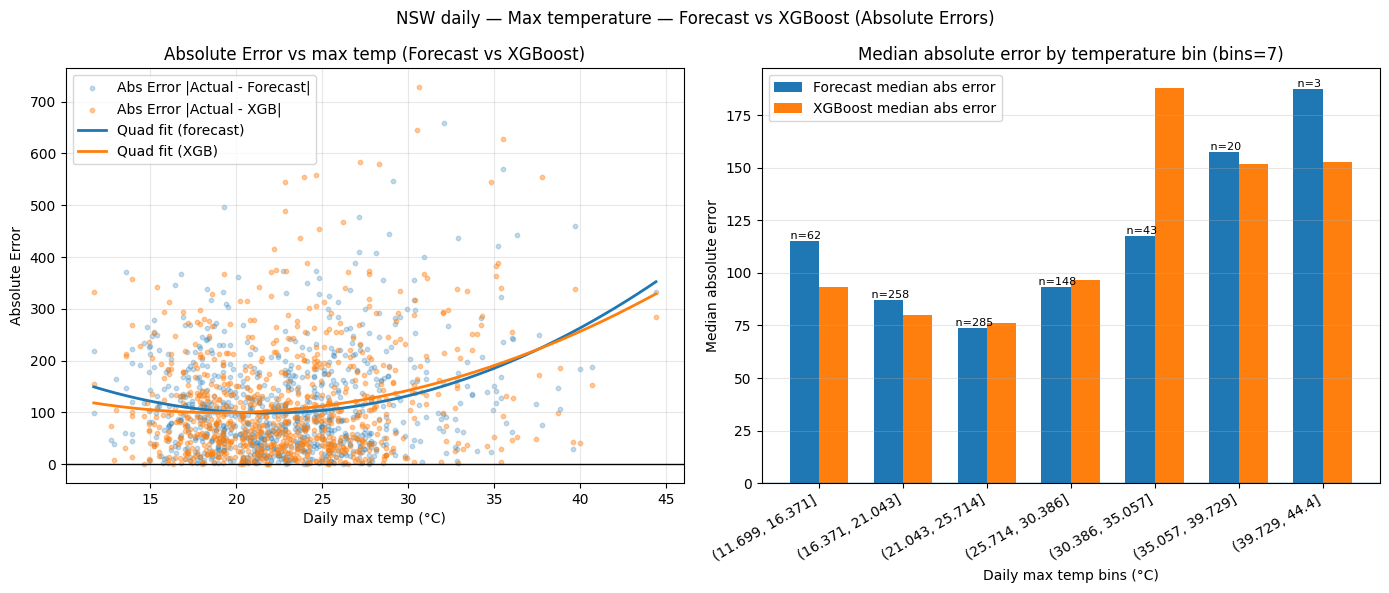


Min Temperature Analysis (XGBoost):


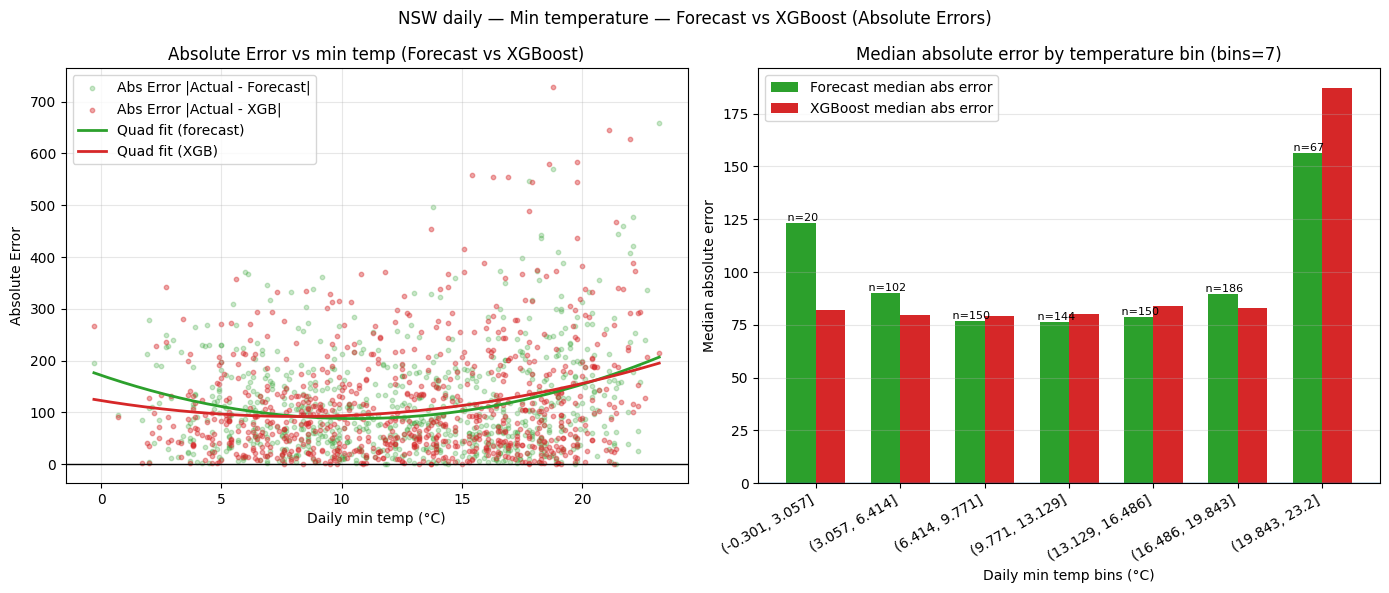


Improvement by temperature extremes (XGBoost):
Hot days (max >35°C): {'n': 23, 'forecast_MAE': 220.23157562684176, 'forecast_R2': 0.8865623994930916, 'xgb_MAE': 206.97149654664864, 'xgb_R2': 0.8803955378012698, 'MAE_reduction': 13.260079080193123, 'R2_improvement': -0.00616686169182179}
Cold days (min <5°C): {'n': 65, 'forecast_MAE': 108.89350348542838, 'forecast_R2': 0.9571127014712028, 'xgb_MAE': 89.58906099759615, 'xgb_R2': 0.9681173789148201, 'MAE_reduction': 19.304442487832233, 'R2_improvement': 0.011004677443617328}
Normal days: {'n': 731, 'forecast_MAE': 109.53627757824971, 'forecast_R2': 0.9650931294670616, 'xgb_MAE': 113.81594955115037, 'xgb_R2': 0.9590354106161177, 'MAE_reduction': -4.279671972900658, 'R2_improvement': -0.006057718850943861}

Original Model (Forecast) Accuracy:
Forecast MSE: 21588.61
Forecast R2: 0.9668

XGBoost Model Accuracy:
XGBoost MSE: 24482.86
XGBoost R2: 0.9624


In [6]:
# Predict
pred_train = best_model.predict(X_train)
pred_test  = best_model.predict(X_test)
pred_all   = best_model.predict(X)

# Attach predictions and residuals to a DataFrame for analysis
results_df = X_test.copy()
results_df['ACTUAL'] = y_test
results_df['PRED_XGB'] = y_pred
# Make sure the index alignment is correct and the forecast series matches the test set
forecast_test = df_daily['FORECASTDEMAND']['mean'].reindex(X_test.index)
results_df['FORECAST'] = forecast_test.values  # Add forecast as a baseline
results_df['RESID_FORECAST'] = results_df['ACTUAL'] - results_df['FORECAST']
results_df['RESID_XGB'] = results_df['ACTUAL'] - results_df['PRED_XGB']

# Metrics
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    # R-squared
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    metrics = {"MAE":mae, "RMSE":rmse, "MAPE_pct":mape, "R2":r2}
    return metrics
metrics_forecast_test = metrics(y_test, results_df["FORECAST"])
metrics_xgb_test = metrics(y_test, y_pred)
# Print metrics, ensuring no np.float types in output
def to_builtin_type(obj):
    if isinstance(obj, dict):
        return {k: to_builtin_type(v) for k, v in obj.items()}
    elif isinstance(obj, (np.generic, np.ndarray)):
        return obj.item() if hasattr(obj, 'item') else obj.tolist()
    else:
        return obj

print("Forecast on test:", to_builtin_type(metrics_forecast_test))
print("XGBoost on test:", to_builtin_type(metrics_xgb_test))

# Calculate improvement
mae_improvement = metrics_forecast_test["MAE"] - metrics_xgb_test["MAE"]
rmse_improvement = metrics_forecast_test["RMSE"] - metrics_xgb_test["RMSE"]
r2_improvement = metrics_xgb_test["R2"] - metrics_forecast_test["R2"]
print(f"\nMAE improvement: {mae_improvement:.1f} MW ({mae_improvement/metrics_forecast_test['MAE']*100:.1f}%)")
print(f"RMSE improvement: {rmse_improvement:.1f} MW ({rmse_improvement/metrics_forecast_test['RMSE']*100:.1f}%)")
print(f"R² improvement: {r2_improvement:.3f} ({r2_improvement/metrics_forecast_test['R2']*100:.1f}%)")

def plot_compare_xgb_max_temp(dframe, bins=7):
    dd = dframe.dropna(subset=['temp_max', 'RESID_XGB', 'RESID_FORECAST']).copy()
    if dd.empty:
        print("No data")
        return

    x = dd['temp_max'].to_numpy()
    e_xgb = np.abs(dd['RESID_XGB'].to_numpy())
    e_fc = np.abs(dd['RESID_FORECAST'].to_numpy())

    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_xgb, e_fit_xgb = quad_fit(x, e_xgb)
    xg_fc, e_fit_fc = quad_fit(x, e_fc)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Abs Error |Actual - Forecast|", color="C0")
    axs[0].scatter(x, e_xgb, alpha=0.4, s=10, label="Abs Error |Actual - XGB|", color="C1")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C0", label="Quad fit (forecast)")
    if xg_xgb.size: axs[0].plot(xg_xgb, e_fit_xgb, linewidth=2, color="C1", label="Quad fit (XGB)")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Absolute Error")
    axs[0].set_title("Absolute Error vs max temp (Forecast vs XGBoost)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(dd['temp_max'].min(), dd['temp_max'].max(), bins+1)
    dd = dd.assign(
        TEMP_BIN=pd.cut(dd['temp_max'], bins=edges, include_lowest=True),
        ABS_RESID_XGB=np.abs(dd['RESID_XGB']),
        ABS_RESID_FORECAST=np.abs(dd['RESID_FORECAST'])
    )
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(
        med_err_fc=("ABS_RESID_FORECAST","median"),
        count=("ABS_RESID_FORECAST","size")
    ).reset_index()
    g_xgb = dd.groupby("TEMP_BIN", observed=True).agg(
        med_err_xgb=("ABS_RESID_XGB","median")
    ).reset_index()
    g = g_fc.merge(g_xgb, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median abs error", color="C0")
    axs[1].bar(idx + width/2, g["med_err_xgb"], width=width, label="XGBoost median abs error", color="C1")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median absolute error")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, xgbv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_xgb"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle("NSW daily — Max temperature — Forecast vs XGBoost (Absolute Errors)")
    plt.tight_layout(); plt.show()
def plot_compare_xgb_min_temp(dframe, bins=7):
    dd = dframe.dropna(subset=['temp_min', 'RESID_XGB', 'RESID_FORECAST']).copy()
    if dd.empty:
        print("No data")
        return

    x = dd['temp_min'].to_numpy()
    e_xgb = np.abs(dd['RESID_XGB'].to_numpy())
    e_fc = np.abs(dd['RESID_FORECAST'].to_numpy())

    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_xgb, e_fit_xgb = quad_fit(x, e_xgb)
    xg_fc, e_fit_fc = quad_fit(x, e_fc)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Abs Error |Actual - Forecast|", color="C2")
    axs[0].scatter(x, e_xgb, alpha=0.4, s=10, label="Abs Error |Actual - XGB|", color="C3")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C2", label="Quad fit (forecast)")
    if xg_xgb.size: axs[0].plot(xg_xgb, e_fit_xgb, linewidth=2, color="C3", label="Quad fit (XGB)")
    axs[0].set_xlabel("Daily min temp (°C)"); axs[0].set_ylabel("Absolute Error")
    axs[0].set_title("Absolute Error vs min temp (Forecast vs XGBoost)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(dd['temp_min'].min(), dd['temp_min'].max(), bins+1)
    dd = dd.assign(
        TEMP_BIN=pd.cut(dd['temp_min'], bins=edges, include_lowest=True),
        ABS_RESID_XGB=np.abs(dd['RESID_XGB']),
        ABS_RESID_FORECAST=np.abs(dd['RESID_FORECAST'])
    )
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(
        med_err_fc=("ABS_RESID_FORECAST","median"),
        count=("ABS_RESID_FORECAST","size")
    ).reset_index()
    g_xgb = dd.groupby("TEMP_BIN", observed=True).agg(
        med_err_xgb=("ABS_RESID_XGB","median")
    ).reset_index()
    g = g_fc.merge(g_xgb, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median abs error", color="C2")
    axs[1].bar(idx + width/2, g["med_err_xgb"], width=width, label="XGBoost median abs error", color="C3")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily min temp bins (°C)"); axs[1].set_ylabel("Median absolute error")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, xgbv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_xgb"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle("NSW daily — Min temperature — Forecast vs XGBoost (Absolute Errors)")
    plt.tight_layout(); plt.show()
def improvement_by_temp_extremes(dframe):
    hot = dframe.loc[dframe["is_extreme_hot"] == 1] # Max temp > 35°C
    cold = dframe.loc[dframe["is_extreme_cold"] == 1] # Min temp < 5°C
    normal = dframe.loc[(dframe["is_extreme_hot"] == 0) & (dframe["is_extreme_cold"] == 0)]
    
    def comp(sub, label):
        if len(sub)==0: return {}
        fc = metrics(sub["ACTUAL"].values, sub["FORECAST"].values)
        xgb = metrics(sub["ACTUAL"].values, sub["PRED_XGB"].values)
        return {label: {"n":len(sub), "forecast_MAE":fc["MAE"], "forecast_R2":fc["R2"],
                "xgb_MAE":xgb["MAE"], "xgb_R2":xgb["R2"],
                "MAE_reduction": fc["MAE"]-xgb["MAE"], "R2_improvement": xgb["R2"]-fc["R2"]}}

    print("\nImprovement by temperature extremes (XGBoost):")
    result = {}
    result.update(comp(hot, "Hot days (max >35°C)"))
    result.update(comp(cold, "Cold days (min <5°C)"))
    result.update(comp(normal, "Normal days"))

    for key, values in result.items():
        clean_values = {k: float(v) if isinstance(v, np.generic) else v for k, v in values.items()}
        print(f"{key}: {clean_values}")

    # Compare to original model (forecast) accuracy
    print("\nOriginal Model (Forecast) Accuracy:")
    mse_forecast = mean_squared_error(dframe['ACTUAL'], dframe['FORECAST'])
    r2_forecast = r2_score(dframe['ACTUAL'], dframe['FORECAST'])
    print(f"Forecast MSE: {mse_forecast:.2f}")
    print(f"Forecast R2: {r2_forecast:.4f}")

    print("\nXGBoost Model Accuracy:")
    mse_xgb = mean_squared_error(dframe['ACTUAL'], dframe['PRED_XGB'])
    r2_xgb = r2_score(dframe['ACTUAL'], dframe['PRED_XGB'])
    print(f"XGBoost MSE: {mse_xgb:.2f}")
    print(f"XGBoost R2: {r2_xgb:.4f}")

print("Max Temperature Analysis (XGBoost):")
plot_compare_xgb_max_temp(results_df)
print("\nMin Temperature Analysis (XGBoost):")
plot_compare_xgb_min_temp(results_df)
improvement_by_temp_extremes(results_df)

In [ ]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Demand', color='blue')
plt.plot(y_pred, label='Predicted Demand', color='red', alpha=0.7)
plt.title('Actual vs Predicted Energy Demand')
plt.xlabel('Test Sample')
plt.ylabel('Energy Demand')
plt.legend()
plt.show()

# Scatter plot of actual vs predicted

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand (Scatter)')
plt.show()

# Feature importance plot
xgb.plot_importance(best_model)
# Tree plot with higher resolution
xgb.plot_tree(best_model, num_trees=0)
plt.savefig("xgboost-plots/xgboost_tree.png", dpi=1200, bbox_inches='tight')
